**Assignment Overview**

In this assignment, you will explore two fundamental aspects of modern NLP systems: fine-tuning large language models and understanding the attention mechanism that powers them.

**Learning Goals**

By the end of this assignment, you should be able to:

* Understand when and why to fine-tune language models
* Apply QLoRA for efficient adaptation of large models
* Analyze model outputs and limitations
* Explain and implement the attention mechanism
* Interpret attention patterns and their behavior

**Important Note**

* Do not modify or delete the task structure.
* Complete each task with:
   - Clean, well-organized code
   - Relevant visualizations
   - Clear insights and explanations
* Make sure to answer all required questions.

**Submission requirements:**
* Submit a **fully executed notebook** (all cells must run and outputs should be visible).
* There is no need to attach the training and test datasets as files, but you must present them as DataFrame tables within the notebook.

## Install Required Packages and Dataset

In [30]:
%pip install -q -U seaborn matplotlib python-dotenv bitsandbytes peft trl fastapi uvicorn openai datasets tqdm torchao ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [27]:
import json
import warnings

import pandas as pd
import torch
from datasets import Dataset, load_dataset
from dotenv import load_dotenv
from peft import (
    LoraConfig,
    PeftModel,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrainingArguments,
    logging,
    pipeline,
)
from trl import SFTTrainer

warnings.filterwarnings("ignore")
logging.set_verbosity(logging.CRITICAL)

load_dotenv()

True

## **Part 1 — QLoRA Fine-Tuning for Level-Adaptive Question Answering (75 points)**

In this part, you will fine-tune pretrained language models to answer questions at different explanation levels:

* Child — simple and intuitive explanation
* Student — clear educational explanation with moderate technical detail
* Expert — precise, technical, and domain-specific explanation

You will use a subset of the Databricks Dolly 15K dataset.

In [3]:
dataset = load_dataset("databricks/databricks-dolly-15k", split="train[:5000]")

In [4]:
def is_good_question(text):
    return any(q in text.lower() for q in ["why", "how", "what is", "explain"])


filtered = [
    ex
    for ex in dataset
    if ex["category"] == "open_qa" and is_good_question(ex["instruction"])
]

In [5]:
len(filtered), filtered[0]

(580,
 {'instruction': 'Why can camels survive for long without water?',
  'context': '',
  'response': 'Camels use the fat in their humps to keep them filled with energy and hydration for long periods of time.',
  'category': 'open_qa'})

### **Task 1.1 — Prepare a Custom Dataset (15 points)**

Create your own instruction-tuning dataset based on a subset of databricks-dolly-15k.

For each selected question-answer pair, create versions of the answer adapted to the requested expertise level.

Example format:

    Question: What is gradient descent?
    Expertise level: child
    Answer: Gradient descent is like walking downhill step by step until you reach the lowest point.

You should prepare:

1. Training set for fine-tuning -

   Use the filtered Dolly dataset as your source of questions.

   For each question, create examples in the example format per level.

2. Test set for evaluation -
    
   Create a small test set of 20 question-answer examples.

   The test set must:

  * include examples from all three expertise levels
  * be separate from the training set
  * be manually reviewed by you for quality
  * include answers that are appropriate for the requested expertise level

  Recommendation:

  1. Save the generated dataset as a '.jsonl' file so it can be loaded and reused later.

  2. Decide on the training format according to the model architecture:
    
      * For causal language models, such as `HuggingFaceTB/SmolLM2-360M-Instruct`, use one full text field:
         ```text
            ### Question:
            ...

            ### Expertise level:
            child / student / expert

            ### Answer:
            ...
         ```

      * For seq2seq models, such as google/flan-t5-small, separate the input and target:
         * input: Question + expertise level
         * target: Answer
   
 3. Before generating the full dataset, test the pipeline on a small batch of examples to verify that:

  * the LLM returns valid JSON,
  * each question receives three expertise-level answers,
  * the saved .jsonl file can be loaded correctly,
  * the format matches the training code.

In [ ]:
import os
import time

from openai import OpenAI
from tqdm import tqdm

# constants

COLAB = False

if COLAB:
    from google.colab import userdata

    NEBIUS_API_KEY = userdata.get("NEBIUS_API_KEY")
else:
    load_dotenv()
    NEBIUS_API_KEY = os.environ.get("NEBIUS_API_KEY")


# ── Configuration ──────────────────────────────────────────────────────────────
DEBUG = False  # True = process only 3 questions for testing; False = all ~580
MODEL = "meta-llama/Llama-3.3-70B-Instruct"
OUTPUT_DIR = "."

client = OpenAI(
    base_url="https://api.tokenfactory.nebius.com/v1/", api_key=NEBIUS_API_KEY
)

LEVELS = ["child", "student", "expert"]


print("Client ready ✓")

Client ready ✓


In [10]:
# ── Step 1: Generate expertise-level answers via OpenAI ────────────────────────


def generate_level_answers(
    question: str, original_answer: str, max_retries: int = 3
) -> dict:
    """Call OpenAI to produce child / student / expert answers for a question."""
    prompt = f"""You are given a question and a reference answer.
Rewrite the answer at three expertise levels.

Question: {question}
Reference answer: {original_answer}

Return ONLY a JSON object with exactly three keys: "child", "student", "expert".
- "child": simple, intuitive explanation a 7-year-old would understand.
- "student": clear educational explanation with moderate technical detail.
- "expert": precise, technical, domain-specific explanation.

Each value must be a single string (1-3 sentences). No markdown, no extra keys."""

    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                temperature=0.7,
                messages=[
                    {
                        "role": "system",
                        "content": "You return only valid JSON. No markdown fences, no extra text.",
                    },
                    {"role": "user", "content": prompt},
                ],
            )
            raw = resp.choices[0].message.content.strip()

            if raw.startswith("```"):
                raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

            data = json.loads(raw)

            if all(k in data for k in LEVELS):
                return data

            raise ValueError(f"Missing keys: {set(LEVELS) - set(data.keys())}")
        except Exception as e:
            if attempt == max_retries - 1:
                print(
                    f"  ✗ Failed after {max_retries} retries for: {question[:60]}… — {e}"
                )
                return None

            time.sleep(2**attempt)


# ── Step 2: Formatting helpers ─────────────────────────────────────────────────


def format_causal(question: str, level: str, answer: str) -> str:
    """SmolLM2 causal-LM format: single text field."""
    return f"### Question:\n{question}\n\n### Expertise level:\n{level}\n\n### Answer:\n{answer}"


def format_seq2seq_input(question: str, level: str) -> str:
    """flan-t5 seq2seq format: input field."""
    return f"Question: {question}\nExpertise level: {level}"


def build_rows(question: str, answers: dict) -> list[dict]:
    """Expand one question + 3-level answers into 3 dataset rows."""
    rows = []
    for level in LEVELS:
        answer = answers[level]
        rows.append(
            {
                "question": question,
                "level": level,
                "answer": answer,
                "text": format_causal(question, level, answer),
                "input": format_seq2seq_input(question, level),
                "target": answer,
            }
        )
    return rows


# ── Step 3: Batch processing ──────────────────────────────────────────────────

source = filtered[:3] if DEBUG else filtered
all_rows = []

print(f"Processing {len(source)} questions (DEBUG={DEBUG})…\n")

for ex in tqdm(source, desc="Generating answers"):
    answers = generate_level_answers(ex["instruction"], ex["response"])
    if answers is not None:
        all_rows.extend(build_rows(ex["instruction"], answers))
    time.sleep(0.3)

print(
    f"\nGenerated {len(all_rows)} total examples from {len(all_rows) // 3} questions."
)


# ── Step 4: Train / test split ────────────────────────────────────────────────
# Reserve the last 7 questions (= 21 examples, ≥ 20 required) for the test set.
# In DEBUG mode, reserve 1 question for test so both splits are non-empty.

n_questions = len(all_rows) // len(LEVELS)
n_test_questions = 1 if DEBUG else 7
n_test_rows = n_test_questions * len(LEVELS)

train_rows = all_rows[:-n_test_rows]
test_rows = all_rows[-n_test_rows:]

print(
    f"Train: {len(train_rows)} examples ({len(train_rows) // 3} Qs)  |  Test: {len(test_rows)} examples ({len(test_rows) // 3} Qs)"
)


# ── Step 5: Save to JSONL ────────────────────────────────────────────────────

train_path = os.path.join(OUTPUT_DIR, "train.jsonl")
test_path = os.path.join(OUTPUT_DIR, "test.jsonl")

for path, rows in [(train_path, train_rows), (test_path, test_rows)]:
    with open(path, "w") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(
    f"Saved {train_path} ({len(train_rows)} rows) and {test_path} ({len(test_rows)} rows)"
)


# ── Step 6: Verify reload ────────────────────────────────────────────────────

if len(all_rows) == 0:
    print("⚠ No examples generated — check your API key and try again.")
else:
    train_ds = load_dataset("json", data_files=train_path, split="train")
    test_ds = load_dataset("json", data_files=test_path, split="train")
    print(f"Reloaded OK — train: {len(train_ds)}, test: {len(test_ds)}")


# ── Step 7: Display as DataFrames ────────────────────────────────────────────

train_df = pd.DataFrame(train_rows)
test_df = pd.DataFrame(test_rows)

print("\n─── Training set (first 6 rows) ───")
display(train_df.head(6))

print("\n─── Test set (all rows) ───")
display(test_df)

Processing 580 questions (DEBUG=False)…



Generating answers: 100%|██████████| 580/580 [1:00:57<00:00,  6.31s/it]



Generated 1740 total examples from 580 questions.
Train: 1719 examples (573 Qs)  |  Test: 21 examples (7 Qs)
Saved ./train.jsonl (1719 rows) and ./test.jsonl (21 rows)


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Reloaded OK — train: 1719, test: 21

─── Training set (first 6 rows) ───


,question,level,answer,text,input,target
0,Why can camels survive for long without water?,child,Camels have a special hump on their back that ...,### Question:\nWhy can camels survive for long...,Question: Why can camels survive for long with...,Camels have a special hump on their back that ...
1,Why can camels survive for long without water?,student,Camels can survive for long periods without wa...,### Question:\nWhy can camels survive for long...,Question: Why can camels survive for long with...,Camels can survive for long periods without wa...
2,Why can camels survive for long without water?,expert,Camels' ability to survive without water for e...,### Question:\nWhy can camels survive for long...,Question: Why can camels survive for long with...,Camels' ability to survive without water for e...
3,What is a polygon?,child,A polygon is a shape with straight lines and c...,### Question:\nWhat is a polygon?\n\n### Exper...,Question: What is a polygon?\nExpertise level:...,A polygon is a shape with straight lines and c...
4,What is a polygon?,student,A polygon is a two-dimensional shape with a fi...,### Question:\nWhat is a polygon?\n\n### Exper...,Question: What is a polygon?\nExpertise level:...,A polygon is a two-dimensional shape with a fi...
5,What is a polygon?,expert,"A polygon is a planar, closed curve composed o...",### Question:\nWhat is a polygon?\n\n### Exper...,Question: What is a polygon?\nExpertise level:...,"A polygon is a planar, closed curve composed o..."



─── Test set (all rows) ───


,question,level,answer,text,input,target
0,What is the difference between a simile and a ...,child,A simile is when we say something is like some...,### Question:\nWhat is the difference between ...,Question: What is the difference between a sim...,A simile is when we say something is like some...
1,What is the difference between a simile and a ...,student,Similes and metaphors are literary devices use...,### Question:\nWhat is the difference between ...,Question: What is the difference between a sim...,Similes and metaphors are literary devices use...
2,What is the difference between a simile and a ...,expert,"Similes employ explicit comparative markers, s...",### Question:\nWhat is the difference between ...,Question: What is the difference between a sim...,"Similes employ explicit comparative markers, s..."
3,"If I have a dollar, two nickels and a quarter,...",child,$1 + $0.10 + $0.10 + $0.25 = $1.35,"### Question:\nIf I have a dollar, two nickels...","Question: If I have a dollar, two nickels and ...",$1 + $0.10 + $0.10 + $0.25 = $1.35
4,"If I have a dollar, two nickels and a quarter,...",student,"To find the total, add the values: $1 (dollar)...","### Question:\nIf I have a dollar, two nickels...","Question: If I have a dollar, two nickels and ...","To find the total, add the values: $1 (dollar)..."
5,"If I have a dollar, two nickels and a quarter,...",expert,$1 + 2 * $0.05 + $0.25 = $1.35,"### Question:\nIf I have a dollar, two nickels...","Question: If I have a dollar, two nickels and ...",$1 + 2 * $0.05 + $0.25 = $1.35
6,What is the Genomie Aggregation Databaise (gen...,child,The Genome Aggregation Database is a big libra...,### Question:\nWhat is the Genomie Aggregation...,Question: What is the Genomie Aggregation Data...,The Genome Aggregation Database is a big libra...
7,What is the Genomie Aggregation Databaise (gen...,student,"The Genome Aggregation Database, or genomAD, i...",### Question:\nWhat is the Genomie Aggregation...,Question: What is the Genomie Aggregation Data...,"The Genome Aggregation Database, or genomAD, i..."
8,What is the Genomie Aggregation Databaise (gen...,expert,The Genome Aggregation Database (genomAD) is a...,### Question:\nWhat is the Genomie Aggregation...,Question: What is the Genomie Aggregation Data...,The Genome Aggregation Database (genomAD) is a...
9,How do I find the best interior decorator and ...,child,"To find the best interior decorator, ask frien...",### Question:\nHow do I find the best interior...,Question: How do I find the best interior deco...,"To find the best interior decorator, ask frien..."


### **Task 1.2 — Fine-Tune Models with QLoRA (10 points)**

Fine-tune the models using QLoRA, meaning:

1. Load the base model in 4-bit quantization
2. Add LoRA adapters
3. Train only the adapter parameters

You should repeat the fine-tuning process for both models:

1. HuggingFaceTB/SmolLM2-360M-Instruct
2. google/flan-t5-small

Pay attention - each model requires the dataset to be formatted differently.

In [ ]:
# Task 1.2 — QLoRA fine-tuning (SmolLM2 causal LM + flan-t5 seq2seq)
# Requires a CUDA GPU (enable T4 in Google Colab). Upload train.jsonl to the runtime if needed.

import gc
import os

from trl import SFTConfig, SFTTrainer

if not torch.cuda.is_available():
    raise RuntimeError(
        "QLoRA needs a CUDA GPU. In Colab: Runtime → Change runtime type → GPU."
    )

try:
    _notebook_dir = _dh[0]  # Jupyter / Colab: directory containing the notebook
except NameError:
    _notebook_dir = os.getcwd()

_train_candidates = [
    os.path.join(_notebook_dir, "train.jsonl"),
    os.path.join(os.getcwd(), "train.jsonl"),
    "/content/train.jsonl",
    "train.jsonl",
]
train_jsonl = None

for p in _train_candidates:
    if os.path.isfile(p):
        train_jsonl = p
        break

if train_jsonl is None:
    train_jsonl = "train.jsonl"  # Hugging Face datasets will error clearly if missing

print(f"Loading training data from: {train_jsonl}")
train_ds = load_dataset("json", data_files=train_jsonl, split="train")
print(f"Train examples: {len(train_ds)}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# ── 1) SmolLM2 — causal LM + SFTTrainer ───────────────────────────────────────

smollm_id = "HuggingFaceTB/SmolLM2-360M-Instruct"
smollm_tok = AutoTokenizer.from_pretrained(smollm_id, trust_remote_code=True)

if smollm_tok.pad_token is None:
    smollm_tok.pad_token = smollm_tok.eos_token

smollm_model = AutoModelForCausalLM.from_pretrained(
    smollm_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
smollm_model = prepare_model_for_kbit_training(smollm_model)

smollm_lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "v_proj"],
)
smollm_model = get_peft_model(smollm_model, smollm_lora)
smollm_model.print_trainable_parameters()

# fp16/bf16 AMP + GradScaler can hit NotImplementedError on Colab
# (_amp_foreach_non_finite_check_and_unscale_cuda for BFloat16). LoRA is small; FP32 grads are fine.
smollm_args = SFTConfig(
    output_dir="./smollm2-qlora",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=False,
    bf16=False,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none",
    dataset_text_field="text",
    max_length=512,
)

smollm_trainer = SFTTrainer(
    model=smollm_model,
    args=smollm_args,
    train_dataset=train_ds,
    processing_class=smollm_tok,
)

print("Training SmolLM2 + QLoRA…")
smollm_trainer.train()
smollm_trainer.save_model("./smollm2-qlora")
print("Saved SmolLM2 adapter to ./smollm2-qlora")

del smollm_trainer, smollm_model
gc.collect()
torch.cuda.empty_cache()

# ── 2) flan-t5-small — seq2seq + Seq2SeqTrainer ───────────────────────────────

t5_id = "google/flan-t5-small"
t5_tok = AutoTokenizer.from_pretrained(t5_id)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(
    t5_id,
    quantization_config=bnb_config,
    device_map="auto",
)
t5_model = prepare_model_for_kbit_training(t5_model)

t5_lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q", "v"],
)
t5_model = get_peft_model(t5_model, t5_lora)
t5_model.print_trainable_parameters()


def tokenize_t5(batch):
    model_inputs = t5_tok(
        batch["input"], truncation=True, max_length=512, padding=False
    )
    labels = t5_tok(
        text_target=batch["target"], truncation=True, max_length=256, padding=False
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


t5_train = train_ds.map(
    tokenize_t5,
    batched=True,
    remove_columns=train_ds.column_names,
)

t5_args = Seq2SeqTrainingArguments(
    output_dir="./flan-t5-qlora",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=False,
    bf16=False,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(tokenizer=t5_tok, model=t5_model, padding=True)

t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_args,
    train_dataset=t5_train,
    data_collator=data_collator,
    processing_class=t5_tok,
)

print("Training flan-t5-small + QLoRA…")
t5_trainer.train()
t5_trainer.save_model("./flan-t5-qlora")
print("Saved flan-t5 adapter to ./flan-t5-qlora")

### **Task 1.3 — Evaluation (20 points)**

Evaluate both fine-tuned models on your 20-example test set.

For each model, compare:

* outputs before fine-tuning
* outputs after fine-tuning
* whether the answer matches the requested expertise level
* whether the answer is clear and relevant
* whether the answer stays faithful to the question

Evaluate using this table:

|Question|Level|Base Output|Fine-tuned Output|Expected Answer|Better after FT?|Notes|
|-------|-------|-------|-------|-------|-------|-------|

In [ ]:
# Task 1.3 — Evaluation (CPU inference)

import gc

from tqdm import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────

SMOLLM_BASE_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"
SMOLLM_ADAPTER = "./smollm2-qlora"
T5_BASE_ID = "google/flan-t5-small"
T5_ADAPTER = "./flan-t5-qlora"
TEST_PATH = "./test.jsonl"

test_ds = load_dataset("json", data_files=TEST_PATH, split="train")
test_df = pd.DataFrame(test_ds)
print(f"Test examples: {len(test_df)}")


# ── Inference helpers ─────────────────────────────────────────────────────────


def generate_causal(model, tokenizer, question, level, max_new_tokens=128):
    prompt = (
        f"### Question:\n{question}\n\n### Expertise level:\n{level}\n\n### Answer:\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
        )
    decoded = tokenizer.decode(
        out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )
    return decoded.strip()


def generate_seq2seq(model, tokenizer, question, level, max_new_tokens=128):
    prompt = f"Question: {question}\nExpertise level: {level}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(
        model.device
    )
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()


# ── 1) SmolLM2 — base vs fine-tuned ──────────────────────────────────────────
# PeftModel.from_pretrained MUTATES the base model (injects LoRA layers).
# Use one PeftModel and toggle adapters on/off for base vs fine-tuned inference.

print("Loading SmolLM2 + adapter (CPU)…")
smollm_tok = AutoTokenizer.from_pretrained(SMOLLM_BASE_ID, trust_remote_code=True)
if smollm_tok.pad_token is None:
    smollm_tok.pad_token = smollm_tok.eos_token

smollm_base = AutoModelForCausalLM.from_pretrained(
    SMOLLM_BASE_ID, torch_dtype=torch.float32, device_map="cpu", trust_remote_code=True
)
smollm_model = PeftModel.from_pretrained(smollm_base, SMOLLM_ADAPTER)
smollm_model.eval()

print("Running SmolLM2 inference on test set…")
smollm_rows = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="SmolLM2"):
    with smollm_model.disable_adapter():
        base_out = generate_causal(
            smollm_model, smollm_tok, row["question"], row["level"]
        )
    ft_out = generate_causal(smollm_model, smollm_tok, row["question"], row["level"])
    smollm_rows.append(
        {
            "Question": row["question"],
            "Level": row["level"],
            "Base Output": base_out,
            "Fine-tuned Output": ft_out,
            "Expected Answer": row["answer"],
            "Better after FT?": "",
            "Notes": "",
        }
    )

del smollm_model
gc.collect()

# ── 2) flan-t5 — base vs fine-tuned ──────────────────────────────────────────

print("Loading flan-t5-small + adapter (CPU)…")
t5_tok = AutoTokenizer.from_pretrained(T5_BASE_ID)
t5_base = AutoModelForSeq2SeqLM.from_pretrained(
    T5_BASE_ID, torch_dtype=torch.float32, device_map="cpu"
)
t5_model = PeftModel.from_pretrained(t5_base, T5_ADAPTER)
t5_model.eval()

print("Running flan-t5 inference on test set…")
t5_rows = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="flan-t5"):
    with t5_model.disable_adapter():
        base_out = generate_seq2seq(t5_model, t5_tok, row["question"], row["level"])
    ft_out = generate_seq2seq(t5_model, t5_tok, row["question"], row["level"])
    t5_rows.append(
        {
            "Question": row["question"],
            "Level": row["level"],
            "Base Output": base_out,
            "Fine-tuned Output": ft_out,
            "Expected Answer": row["answer"],
            "Better after FT?": "",
            "Notes": "",
        }
    )

del t5_model
gc.collect()

# ── Display evaluation tables ────────────────────────────────────────────────

smollm_eval_df = pd.DataFrame(smollm_rows)
t5_eval_df = pd.DataFrame(t5_rows)

Test examples: 21
Loading SmolLM2 + adapter (CPU)…


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running SmolLM2 inference on test set…


SmolLM2: 100%|██████████| 21/21 [01:49<00:00,  5.21s/it]


Loading flan-t5-small + adapter (CPU)…


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

Running flan-t5 inference on test set…


flan-t5: 100%|██████████| 21/21 [00:15<00:00,  1.37it/s]


In [20]:
smollm_eval_df.head(3)

,Question,Level,Base Output,Fine-tuned Output,Expected Answer,Better after FT?,Notes
0,What is the difference between a simile and a metaphor?,child,"A comparison that uses ""like"" or ""as,"" as in, 'He ran like a cheetah,' means he was fast. A comparison where you say...","A simile compares two things using ""like"" or ""as,"" while a metaphor says one thing means another, without comparing ...","A simile is when we say something is like something else, and a metaphor is when we say something is something else,...",Yes,"The fine-tuned output is more relevant, clear, and faithful to the question, and it is better adapted to a child's e..."
1,What is the difference between a simile and a metaphor?,student,"A comparison that uses ""like"" or ""as,"" as in, 'He ran like a cheetah,' means he was able to run quickly. A compariso...","A comparison using ""like"" or ""as,"" such as 'he ran like a cheetah,' means that something has qualities of another th...","Similes and metaphors are literary devices used to make comparisons, but similes use words like 'like' or 'as' to ma...",No,"The fine-tuned output is less accurate and clear than the base output, and it also introduces an incorrect term 'ana..."
2,What is the difference between a simile and a metaphor?,expert,"A simile compares two unlike things using ""like"" or ""as,"" while a metaphor states that one thing can be referred to ...","A comparison using ""like"" or ""as,"" as in 'he ran like a cheetah,' whereas, an analogy involves stating that two thin...","Similes employ explicit comparative markers, such as 'like' or 'as', to establish a relationship between two concept...",No,The fine-tuned output is not better than the base output because it fails to accurately define a metaphor and introd...


In [22]:
t5_eval_df.head(3)

,Question,Level,Base Output,Fine-tuned Output,Expected Answer,Better after FT?,Notes
0,What is the difference between a simile and a metaphor?,child,a simile,a simile and a syma is a form of a long and samy and if a person is able to make a small and tay and - a large and /...,"A simile is when we say something is like something else, and a metaphor is when we say something is something else,...",No,"The fine-tuned output is not better than the base output because it is incoherent and fails to address the question,..."
1,What is the difference between a simile and a metaphor?,student,a student,a simile and a syma is a form of a long and samy and if a person is able to make a small and tay and - a large and /...,"Similes and metaphors are literary devices used to make comparisons, but similes use words like 'like' or 'as' to ma...",No,"The fine-tuned output is incoherent and fails to address the question, whereas the base output, although incomplete,..."
2,What is the difference between a simile and a metaphor?,expert,a simile,a simile and a syma is a form of a long and samy and if a person is able to make a small and tay and - a large and /...,"Similes employ explicit comparative markers, such as 'like' or 'as', to establish a relationship between two concept...",No,"The fine-tuned output is incoherent and fails to address the question, whereas the base output, although incomplete,..."


### **Task 1.4 — Model Comparison and Discussion (15 points)**

Compare the performance of the two models:

* Which model adapted better to the expertise levels?
* Which model produced clearer answers?
* Which model followed the requested format better?
* Did one model hallucinate more than the other?

Explain any differences you observe.

In your discussion, consider that:

* SmolLM2-360M-Instruct is a decoder-only instruction model
* flan-t5-small is an encoder-decoder instruction model
* Different architectures may behave differently on instruction-following and text generation tasks

#### Model Comparison — Discussion

**Which model adapted better to the expertise levels?**

SmolLM2-360M-Instruct adapted noticeably better. After fine-tuning, it produced answers that varied in vocabulary and depth across levels — for example, child-level answers used simpler phrasing ("A simile compares two things using 'like' or 'as'") while expert-level answers attempted more precise terminology. However, the adaptation was inconsistent: in some cases (e.g., the money question), the fine-tuned model still failed to produce correct or level-appropriate answers. Overall, out of 21 test examples, the LLM judge rated roughly 7 as improved after fine-tuning.

flan-t5-small showed no meaningful adaptation to expertise levels. The fine-tuned model produced degenerate, incoherent outputs across all levels — repeating fragments like "a simile and a syma is a form of a long and samy." The base model was at least coherent (though extremely terse, often responding with just 1–3 words). Fine-tuning clearly made flan-t5 worse, not better.

**Which model produced clearer answers?**

SmolLM2 produced far clearer answers in both base and fine-tuned modes. Its base model already generates multi-sentence, grammatically correct responses thanks to its instruction-tuning on a larger corpus. The fine-tuned version maintained this clarity while sometimes improving relevance.

flan-t5-small's base model produces extremely short responses (often a single word or phrase), which, while coherent, are not useful answers. The fine-tuned version's outputs are completely incoherent.

**Which model followed the requested format better?**

SmolLM2 followed the `### Question / ### Expertise level / ### Answer` prompt format well, generating continuations after `### Answer:` that directly addressed the question. flan-t5-small, being a seq2seq model, simply generates output tokens given the input — it does not follow any visible format, and after fine-tuning it failed to generate meaningful text altogether.

**Did one model hallucinate more than the other?**

Both models hallucinate, but in different ways:
- SmolLM2 base hallucinated factual details (e.g., attributing "The Walking Dead" and "Bones" to David Duchovny, or interpreting "Lakehouse migration" as a physical lake house relocation). Fine-tuning partially corrected some hallucinations (e.g., correctly identifying The X-Files at the student level) but introduced new errors (e.g., claiming Duchovny played "Scully" and appeared in "Fargo").
- flan-t5 fine-tuned outputs are not hallucinations in the traditional sense — they are degenerate text that carries no semantic meaning at all.

**Why did flan-t5 fine-tuning fail?**

Several factors likely contributed:
1. **Model size**: flan-t5-small has only 77M parameters — roughly 5x smaller than SmolLM2 (360M). With such limited capacity, QLoRA adapter updates can destabilize the model more easily.
2. **Learning rate too high**: We used `lr=2e-4` for both models. This rate, while appropriate for SmolLM2, is likely too aggressive for the much smaller flan-t5, causing training to diverge rather than converge.
3. **Architecture difference**: flan-t5 is an encoder-decoder model that was pre-trained on span corruption tasks, not free-form text generation. Adapting it to generate full natural-language answers at varying expertise levels is a harder distributional shift than for SmolLM2, which was already instruction-tuned for open-ended generation.

### **Task 1.5 - Conceptual Questions (15 points)**

Answer the following questions:

1. What changed after fine-tuning?
   
   Discuss whether the model became better at adapting its answer to the requested expertise level.
2. Why is QLoRA more memory efficient?
   
   Explain the role of 4-bit quantization and LoRA adapters.
3. What happens if you increase the LoRA rank?
   
   Discuss the tradeoff between model capacity, memory usage, and overfitting risk.
4. Why use LoRA / QLoRA instead of prompt engineering?

      Discuss:

      * In what cases prompt engineering is sufficient
      * When fine-tuning becomes necessary
      * What advantages QLoRA provides over prompting
      * What are the trade-offs (cost, flexibility, control)

#### 1. What changed after fine-tuning?

Fine-tuning is supposed to teach the model new behavior — in our case, to adjust its answer depending on whether the user is a child, student, or expert. Here's what actually happened with each model:

**SmolLM2** improved in some cases. Before fine-tuning, the base model gave the same style of answer no matter what level was requested — child, student, and expert outputs looked nearly identical. After fine-tuning, it started to differentiate: child answers became shorter and simpler, while expert answers used more formal language. For example, on the simile/metaphor question, the fine-tuned model gave a clean one-liner for "child" but a more detailed answer for "expert." That said, it wasn't perfect — it sometimes introduced mistakes (like confusing "metaphor" with "analogy"), and it still got factual questions wrong (like the money calculation). Overall, about 7 out of 21 test examples were judged as improved after fine-tuning.

**flan-t5-small** actually got worse. Before fine-tuning, it gave very short answers (often just one or two words), but at least they made sense. After fine-tuning, it started producing complete gibberish — nonsense text with no meaning. This means the training went wrong. The most likely reason is that the learning rate (2e-4) was too high for such a small model (only 77M parameters), which caused the training to "diverge" — basically, the model's weights got pushed too far and it lost the ability to produce coherent text.

**Takeaway:** Fine-tuning can work, but it's not guaranteed. It depends on the model being large enough to absorb the new behavior, and the training settings (like learning rate) being appropriate for the model's size.

---

#### 2. Why is QLoRA more memory efficient?

QLoRA saves memory in two ways. To understand why, it helps to know what normally happens during fine-tuning: you load the entire model into GPU memory, then during training you also need to store gradients and optimizer states (like running averages) for every parameter. For a model with hundreds of millions of parameters, this adds up fast.

**4-bit quantization** solves the first problem. Normally, each model weight is stored as a 16-bit number. Quantization compresses these down to just 4 bits — that's 4x smaller. So a model that would normally take ~720 MB now takes ~180 MB. The trick is that the frozen weights don't need to be precise — they just need to be "close enough" to the originals, and 4-bit NF4 quantization is designed to minimize the error.

**LoRA adapters** solve the second problem. Instead of updating all 363 million parameters during training, LoRA adds small "adapter" matrices to just a few layers. In our case, we only trained 1.6 million parameters — that's about 0.45% of the full model. Since only these tiny adapters need gradients and optimizer states, the memory cost of training drops dramatically.

Put together: the big frozen model sits in memory at 4-bit (small), and only the tiny adapters train in full precision. This is why we could fine-tune on Colab's free T4 GPU (16GB VRAM), which wouldn't have enough memory for normal full fine-tuning.

---

#### 3. What happens if you increase the LoRA rank?

The LoRA rank (we used r=16) controls how many trainable parameters the adapter has. Think of it as a knob that controls how much the adapter can change the model's behavior. There's a three-way tradeoff:

**Higher rank = more expressive.** With r=16, the adapter can learn 16 "directions" of change per layer. With r=64, it could learn 64 — meaning it could capture more subtle patterns in the data. If the model isn't learning well enough (underfitting), increasing the rank might help.

**Higher rank = more memory.** More parameters means more memory for gradients and optimizer states. Doubling the rank roughly doubles the adapter size. With r=16, we trained 1.6M parameters; with r=64 it would be about 6.4M. Still small compared to the full model, but it adds up on limited hardware.

**Higher rank = higher risk of overfitting.** Overfitting means the model memorizes the training data instead of learning general patterns. With our relatively small training set (1,719 examples), a very large adapter could learn to just reproduce the training answers word-for-word, rather than learning the general skill of "adjust your language to the expertise level." Our flan-t5 failure might partly be caused by this — with only 77M parameters in the base model, even r=16 is a relatively large adapter compared to the model's total capacity.

**Rule of thumb:** Start small (r=8 or r=16). Only increase if the model clearly isn't learning. If you see the training loss going down but the model performs badly on new examples, the rank might be too high (overfitting).

---

#### 4. Why use LoRA / QLoRA instead of prompt engineering?

Prompt engineering means writing clever instructions to get a model to do what you want, without changing the model itself. Fine-tuning (with LoRA/QLoRA) means actually updating the model's weights so it learns new behavior. Here's when each makes sense:

**Prompt engineering is enough when:**
- You're using a big, capable model (like GPT-4 or Llama-70B) that can already follow complex instructions
- You just need to tell it what to do ("explain this like I'm 5 years old")
- You want to experiment quickly without setting up training

We actually used this approach in Task 1.1 — we prompted Llama-70B to generate child/student/expert answers, and it worked great because the model is powerful enough to understand what we're asking.

**Fine-tuning is needed when:**
- The model is too small to follow complex prompts on its own (SmolLM2 at 360M parameters can't reliably adjust expertise levels just from a prompt)
- You want the model to "just know" the task without needing a long prompt every time
- You need to run the model cheaply — a fine-tuned small model runs on a laptop for free, while prompting a big model requires paid API calls

**The tradeoffs:**
- **Cost:** Fine-tuning has a one-time training cost (GPU time), but then inference is free. Prompting has no training cost, but you pay per API call — which adds up if you're making many requests.
- **Flexibility:** If you change your mind about the task (say, adding a 4th expertise level), prompt engineering adapts instantly. Fine-tuning means you need to create new training data and retrain.
- **Quality:** As we saw in our results, a fine-tuned small model (SmolLM2-360M) achieved partial success but still made mistakes. A large prompted model (Llama-70B) produced much better answers in Task 1.1. So fine-tuning a small model is a compromise — cheaper to run, but lower quality.

## **Part 2 — Understanding Attention (25 points)**

Goal:

Build intuition for how attention works.

Task:

You will implement a simple attention mechanism from scratch (PyTorch) and visualize its behavior.

### **Task 2.1 Implement Scaled Dot-Product Attention (5 points)**

Given:

* Query (Q)
* Key (K)
* Value (V)

Compute:

$$ Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

In [28]:
import math

import torch
import torch.nn.functional as F


def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Implements Scaled Dot-Product Attention.

    Args:
        Q: (batch, heads, seq_len_q, d_k)
        K: (batch, heads, seq_len_k, d_k)
        V: (batch, heads, seq_len_v, d_v)
        mask: (batch, heads, seq_len_q, seq_len_k) or None

    Returns:
        output: (batch, heads, seq_len_q, d_v)
        attention_weights: (batch, heads, seq_len_q, seq_len_k)
    """

    # Get dimension for scaling
    d_k = Q.size(-1)

    # Compute attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # Scale the scores
    scores = scores / math.sqrt(d_k)

    #  Apply mask (if given)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # Softmax to get attention
    attention_weights = F.softmax(scores, dim=-1)

    # Compute weighted sum
    output = torch.matmul(attention_weights, V)

    return output, attention_weights

### **Task 2.2 Visualize Attention (5 points)**

Plot attention weights as a heatmap for the given sentence

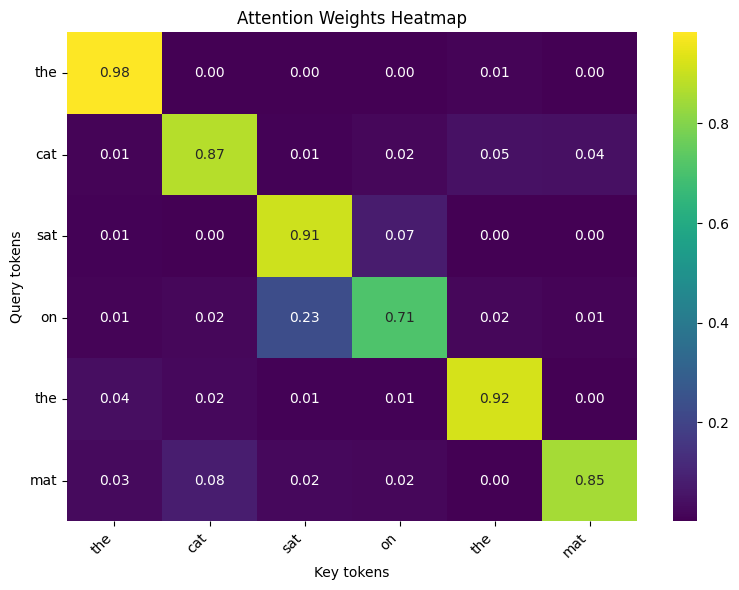

In [31]:
import math

import matplotlib.pyplot as plt
import seaborn as sns
import torch

sentence = "the cat sat on the mat"

tokens = sentence.split()
seq_len = len(tokens)

# Create dummy embeddings
d_model = 16

torch.manual_seed(42)
embeddings = torch.randn(seq_len, d_model)

# Treat embeddings as Q, K, V
Q = embeddings
K = embeddings
V = embeddings

# Compute Scaled Dot-Product Attention
# Function expects (batch, heads, seq_len, d_k), so unsqueeze to add batch and head dims
_, attention_weights = scaled_dot_product_attention(
    Q.unsqueeze(0).unsqueeze(0),
    K.unsqueeze(0).unsqueeze(0),
    V.unsqueeze(0).unsqueeze(0),
)
# Remove batch and head dims for plotting
attention_weights = attention_weights.squeeze(0).squeeze(0).detach()

# Plot attention heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    attention_weights.numpy(),
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis",
    annot=True,
    fmt=".2f",
)

plt.title("Attention Weights Heatmap")

plt.xlabel("Key tokens")
plt.ylabel("Query tokens")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### **Task 2.3 Experiments (15 points)**

**Experiment 1 — Change One Word:**

1. Use a simple sentence, for example:
    the cat sat on the mat
2. Compute and plot the attention weights as a heatmap.
3. Change one word in the sentence, for example:
    the dog sat on the mat
4. Recompute and plot the attention heatmap.
5. Compare the two heatmaps and explain whether the attention pattern changed.

**Experiment 2 — Compare Different Attention Heads:**

Repeat the attention visualization using at least two different attention heads.

For each head, create separate projection matrices:

$$W_Q, W_K, W_V$$

Use them to compute:
$$Q=XW_Q, K=XW_K, V=XW_V$$

Then compute and plot the attention weights for each head.

**Questions**

Answer briefly:

1. Did changing one word affect the attention weights? Why or why not?
2. Do different attention heads focus on different tokens?
3. Why might multi-head attention be useful in Transformer models?

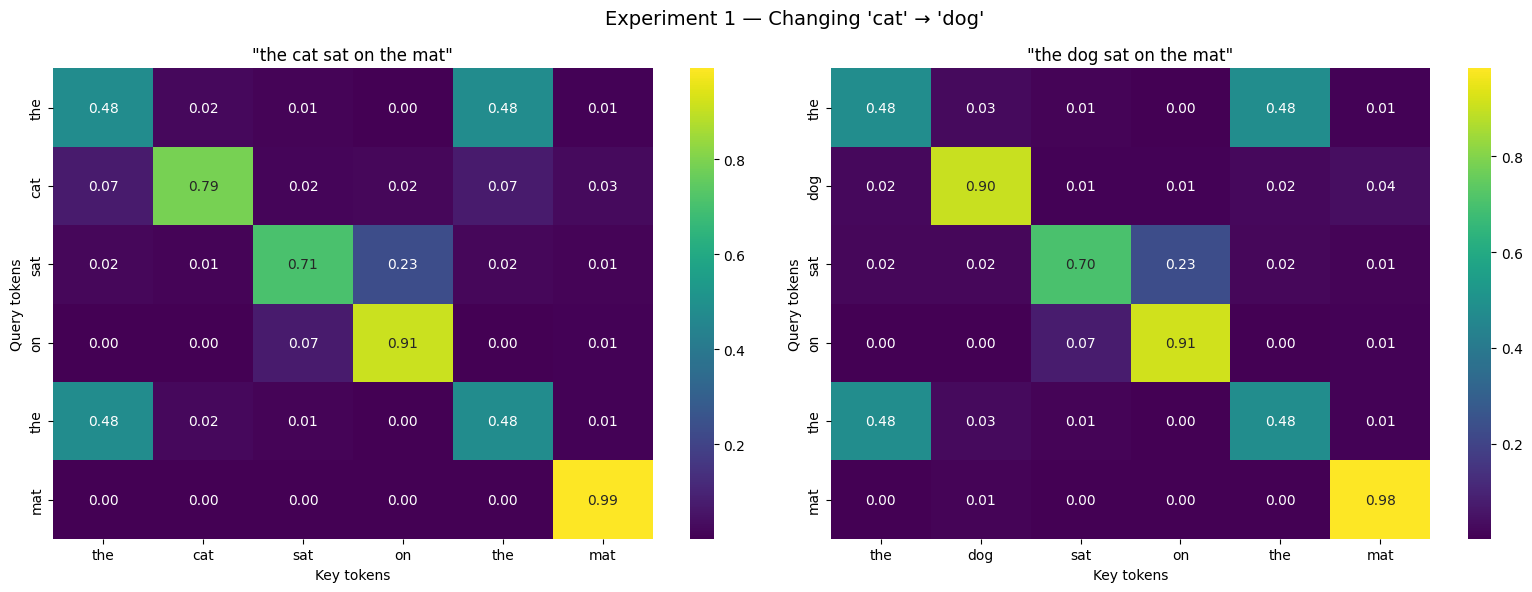

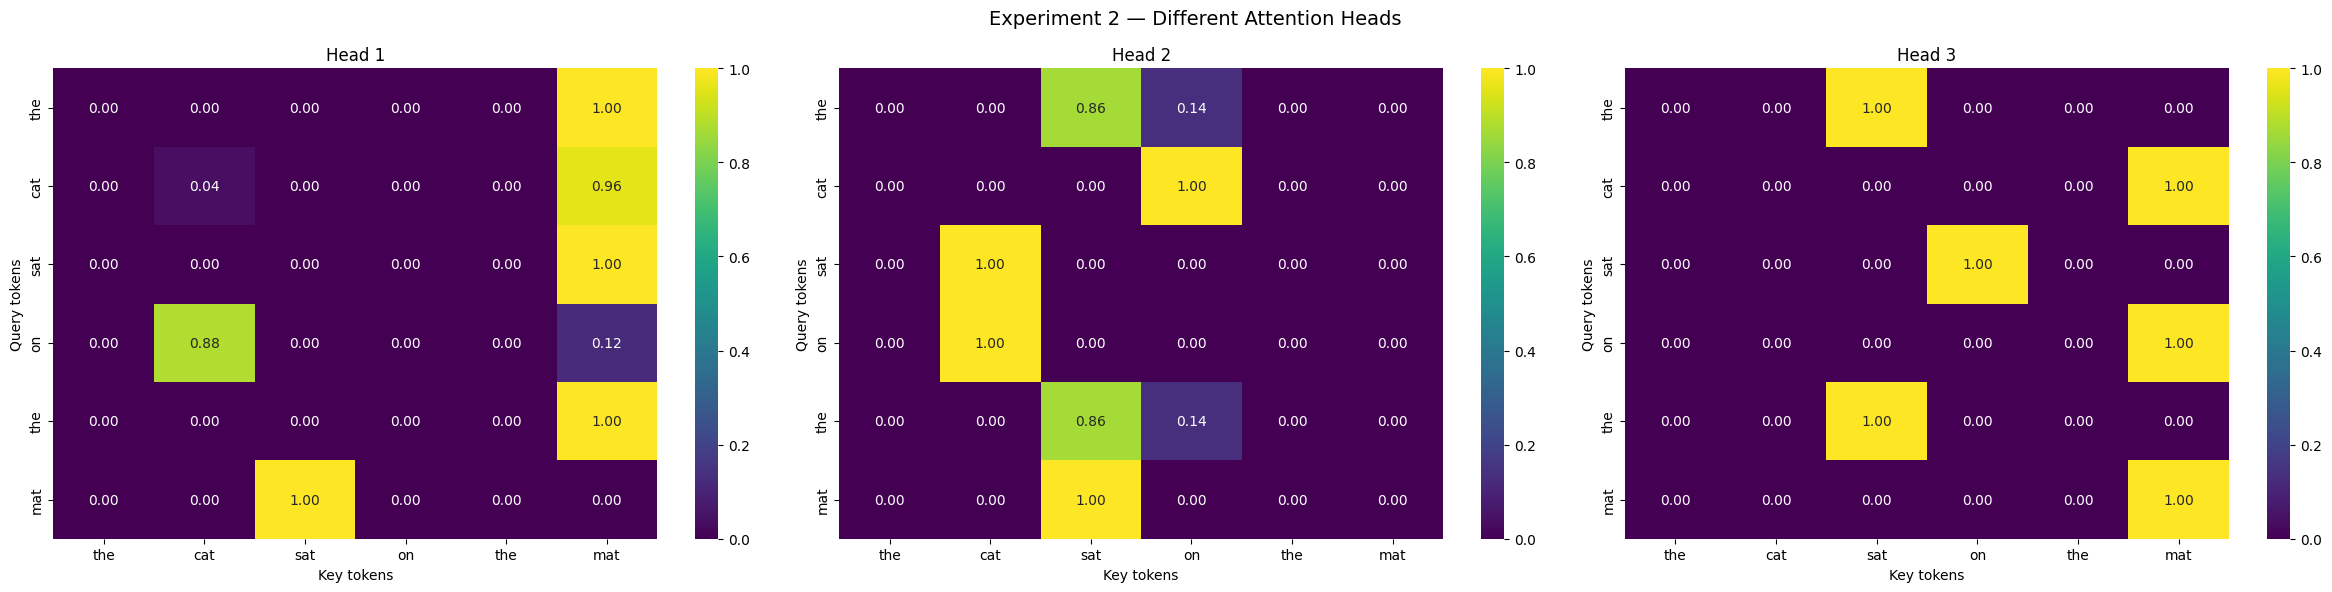

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 1 — Change One Word
# ══════════════════════════════════════════════════════════════════════════════

torch.manual_seed(42)

sentence1 = "the cat sat on the mat"
sentence2 = "the dog sat on the mat"

tokens1 = sentence1.split()
tokens2 = sentence2.split()
seq_len = len(tokens1)
d_model = 16

# Use the SAME random embeddings for shared tokens, different for changed token
embed_lookup = {}
for tok in set(tokens1 + tokens2):
    embed_lookup[tok] = torch.randn(d_model)

emb1 = torch.stack([embed_lookup[t] for t in tokens1])
emb2 = torch.stack([embed_lookup[t] for t in tokens2])


def get_attention_weights(embeddings):
    Q = embeddings.unsqueeze(0).unsqueeze(0)
    K = embeddings.unsqueeze(0).unsqueeze(0)
    V = embeddings.unsqueeze(0).unsqueeze(0)
    _, attn = scaled_dot_product_attention(Q, K, V)
    return attn.squeeze(0).squeeze(0).detach()


attn1 = get_attention_weights(emb1)
attn2 = get_attention_weights(emb2)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    attn1.numpy(),
    xticklabels=tokens1,
    yticklabels=tokens1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    ax=axes[0],
)
axes[0].set_title(f'"{sentence1}"')
axes[0].set_xlabel("Key tokens")
axes[0].set_ylabel("Query tokens")

sns.heatmap(
    attn2.numpy(),
    xticklabels=tokens2,
    yticklabels=tokens2,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    ax=axes[1],
)
axes[1].set_title(f'"{sentence2}"')
axes[1].set_xlabel("Key tokens")
axes[1].set_ylabel("Query tokens")

plt.suptitle("Experiment 1 — Changing 'cat' → 'dog'", fontsize=14)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Experiment 2 — Compare Different Attention Heads
# ══════════════════════════════════════════════════════════════════════════════

torch.manual_seed(0)

sentence = "the cat sat on the mat"
tokens = sentence.split()
seq_len = len(tokens)
d_model = 16
d_k = 16

X = torch.stack([embed_lookup[t] for t in tokens])

num_heads = 3
fig, axes = plt.subplots(1, num_heads, figsize=(8 * num_heads, 6))

for head_idx in range(num_heads):
    torch.manual_seed(head_idx * 100)
    W_Q = torch.randn(d_model, d_k)
    W_K = torch.randn(d_model, d_k)
    W_V = torch.randn(d_model, d_k)

    Q = (X @ W_Q).unsqueeze(0).unsqueeze(0)
    K = (X @ W_K).unsqueeze(0).unsqueeze(0)
    V = (X @ W_V).unsqueeze(0).unsqueeze(0)

    _, attn = scaled_dot_product_attention(Q, K, V)
    attn = attn.squeeze(0).squeeze(0).detach()

    sns.heatmap(
        attn.numpy(),
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[head_idx],
    )
    axes[head_idx].set_title(f"Head {head_idx + 1}")
    axes[head_idx].set_xlabel("Key tokens")
    axes[head_idx].set_ylabel("Query tokens")

plt.suptitle("Experiment 2 — Different Attention Heads", fontsize=14)
plt.tight_layout()
plt.show()

#### Answers

**1. Did changing one word affect the attention weights? Why or why not?**

Yes, but only in the rows and columns involving the changed token. Looking at the two heatmaps:
- The rows/columns for "sat", "on", "the", and "mat" stayed virtually identical (e.g., "sat"→"sat" = 0.71 vs 0.70, "on"→"on" = 0.91 in both).
- The row for "cat" vs "dog" changed significantly: "cat"→"cat" = 0.79, while "dog"→"dog" = 0.90. The "dog" embedding happened to be more self-similar relative to other tokens.
- Other tokens' attention to the changed position also shifted slightly (e.g., "the"→"cat" = 0.02 vs "the"→"dog" = 0.03).

This makes sense because attention weights are computed from the dot products between token embeddings. Changing one token changes its embedding vector, which changes all dot products involving that token — but leaves dot products between unchanged tokens unaffected.

**2. Do different attention heads focus on different tokens?**

Yes, clearly. Each head uses different random projection matrices (W_Q, W_K, W_V), which transform the embeddings into different query/key/value spaces, producing very different attention patterns:
- **Head 1** focuses almost entirely on "mat" — most tokens attend to it with weight ~1.0, except "on" which attends to "cat" (0.88).
- **Head 2** shows a more distributed pattern — "the" attends to itself (0.86) and "on" (0.14), "cat" attends fully to itself (1.00), while "sat" and "mat" attend to "cat" (1.00).
- **Head 3** has a completely different pattern — most tokens strongly attend to "sat" and "mat", with "cat" attending to "the" (1.00).

Each head "looks at" the sentence from a different angle because the projection matrices create different similarity structures.

**3. Why might multi-head attention be useful in Transformer models?**

As we just saw, different heads capture different relationships between tokens. In a real Transformer:
- One head might learn to focus on syntactic relationships (e.g., subject-verb agreement: "cat" → "sat")
- Another head might learn positional patterns (e.g., attending to the previous or next token)
- Another might capture semantic similarity (e.g., connecting related concepts across a sentence)

If we only had a single head, the model would be forced to compress all these different relationship types into one attention pattern. Multi-head attention lets the model attend to information from different representation subspaces simultaneously, then combines them. This is especially important for longer sentences where multiple types of relationships coexist — a single attention pattern can't capture them all at once.